# Pipeline de production — `business_domain`

Ce notebook fait suite au notebook v2 (exploration + modélisation) et couvre
les 4 étapes de mise en production :

| Phase | Objectif |
|---|---|
| **1. Sécuriser les labels** | Audit qualité, nettoyage, génération de files de revue humaine |
| **2. Geler le modèle** | Entraînement final sur données nettoyées, versioning des artefacts |
| **3. Industrialiser l'inférence** | Pipeline de scoring batch, confiance calibrée, monitoring de drift |
| **4. Exploitation métier** | Scoring complet du dataset, rapports, exports pour les équipes |


## 0. Setup

In [5]:
import importlib, subprocess, sys
for pkg in ["lightgbm","joblib","scipy","scikit-learn","pandas","numpy","matplotlib"]:
    try: importlib.import_module(pkg.replace("-","_") if pkg!="scikit-learn" else "sklearn")
    except ImportError: subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import os, re, json, time, warnings, hashlib, datetime
from pathlib import Path
from contextlib import contextmanager
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

@contextmanager
def timer(label):
    t0 = time.perf_counter()
    yield
    print(f"[{label}] {time.perf_counter()-t0:.2f}s")

PIPELINE_VERSION = "v3.0"
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Pipeline {PIPELINE_VERSION} — {TIMESTAMP}")


Pipeline v3.0 — 20260421_110952


## 0.1 Configuration centralisée

In [6]:
RANDOM_STATE = 42
TARGET = "business_domain"

DATA_FILENAME = "exports/dataset_asset_ml_run_5_for_labeling_sample_20000_enriched_business_domain_v4.csv"

OUTPUT_DIR = Path("artifacts_business_domain")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Colonnes à exclure ---
LEAK_COLS = [
    "business_domain_raw","business_domain_label","labeling_notes",
    "llm_votes_json","llm_consensus_score","llm_models_used",
    "llm_prompt_version","llm_status","confidence","reason",
]
ID_COLS = ["run_id","asset_id"]
DROP_COLS = LEAK_COLS + ID_COLS
DROPPED_TEXT_COLS = [
    "column_type_signature_text","column_value_semantics_text",
    "column_sample_values_text","column_observed_pattern_text",
]

TEXT_COLS_CHAR = ["technical_name","source_ref"]
TEXT_COLS_WORD = ["column_names_text"]
NUM_COLS = [
    "field_count","nullable_field_count","non_nullable_field_count",
    "numeric_field_count","date_field_count","text_field_count",
    "large_text_field_count","avg_data_length","max_data_length",
    "row_count","size_bytes","size_mb",
]
CAT_COLS = ["source_system","asset_type","has_profile_data"]

CHAR_MAX_FEATURES = 50_000
WORD_MAX_FEATURES = 80_000
CHAR_NGRAMS = (3, 5)
WORD_NGRAMS = (1, 2)

SQL_STOPWORDS = [
    "varchar2","number","date","timestamp","clob","blob","long",
    "char","raw","xmltype","float","integer","nvarchar2","nclob",
    "timestamp(6)","sysadm","ps",
]

KNOWN_SEMANTIC_LABELS = [
    "label","quantity","identifier","financial_amount","classification",
    "date_or_timestamp","processing_identifier","status",
    "reference_identifier","percentage_or_rate","user_identifier",
    "technical_timestamp","flag","date_part","comment_text",
    "person_identifier","job_label","postal_location","email_address",
    "phone_number","url","score","duration","technical_identifier",
    "person_full_name","person_first_name","person_last_name",
    "file_reference","other","geo_longitude","geo_latitude",
]

# --- Seuils qualité labels ---
CONSENSUS_HARD_FLOOR = 0.5     # en-dessous = retirer
CONSENSUS_SOFT_FLOOR = 0.7     # en-dessous = queue de revue
REVIEW_SAMPLE_SIZE   = 500     # taille max de la file de revue

# --- Modèle de production ---
PROD_MODEL = "LinearSVC"       # champion v2 (Macro-F1=0.878)
CALIBRATE = True               # calibration Platt pour obtenir des probabilités

print("Config chargée.")


Config chargée.


## 0.2 Fonctions partagées (identiques à v2)

In [7]:
DOMAIN_KEYWORDS = {
    "finance": [
        "invoice","payment","ledger","gl","tax","budget","amount",
        "cost","expense","revenue","accounting","journal","account",
        "ap","ar","fi","glacct","treasur","asset","deprec",
        "facture","paiement","comptabil","compte","montant","devise",
        "currency","vat","tva",
    ],
    "hr": [
        "employee","empl","emplid","job","manager","payroll","absence",
        "position","hire","worker","salary","person","headcount",
        "compensation","benefit","pay","leave","employe","salaire",
        "poste","conge",
    ],
    "it": [
        "user","role","access","auth","permission","config","server",
        "system","login","application","security","sysadm",
        "menu","page","xlat","dbowner","portal","prcs","audit",
    ],
    "procurement": [
        "vendor","supplier","purchase","po_","item","stock","inventory",
        "material","order","sourcing","rfq","contract",
        "fournisseur","achat","commande",
    ],
    "sales": [
        "customer","client","opportunity","quote","deal","crm",
        "sales","pipeline","booking","cust_","cust",
        "vente","facturation",
    ],
    "marketing": [
        "campaign","lead","segment","channel","audience","click",
        "impression","conversion","promo",
    ],
    "risk": [
        "risk","control","incident","compliance","issue",
        "mitigation","policy","controle","conformite",
    ],
    "supply_chain": [
        "shipment","warehouse","delivery","route",
        "transport","plant","logistics","bom","prod_",
        "livraison","entrepot","logistique","production",
    ],
}

PS_MODULE_PREFIXES = {
    "GL":"finance","AP":"finance","AR":"finance","AM":"finance",
    "BI":"finance","TR":"finance","EX":"finance",
    "HR":"hr","JOB":"hr","PERSON":"hr","BEN":"hr","PAY":"hr",
    "ABS":"hr","COMP":"hr",
    "PO":"procurement","EP":"procurement","RFQ":"procurement",
    "CON":"procurement","VND":"procurement",
    "IN":"supply_chain","PL":"supply_chain","SF":"supply_chain",
    "MG":"supply_chain","PROD":"supply_chain",
    "SA":"sales","OM":"sales","CRM":"sales",
    "PRCS":"it","PSAUTH":"it","PSOPR":"it","PSROLE":"it",
    "PT":"it","PSMENU":"it",
}

def normalize_text(x):
    if pd.isna(x): return ""
    x = str(x).lower()
    for sep in ["_","-","|","/","\\",".",":",";" ,",","(",")","[","]","{","}"]:
        x = x.replace(sep, " ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    return re.sub(r"\s+", " ", x).strip()

def safe_div(a, b):
    a, b = np.asarray(a, dtype=np.float32), np.asarray(b, dtype=np.float32)
    return np.divide(a, b, out=np.zeros_like(a), where=b!=0)

def extract_prefix(tname):
    if not isinstance(tname, str): return ""
    s = re.sub(r"^[A-Z]+\.", "", tname.upper())
    s = re.sub(r"^PS[_]?", "", s)
    m = re.match(r"([A-Z]+)_", s)
    return m.group(1) if m else s.split("_")[0][:6]

def extract_semantic_profile(semantics_text):
    counts = Counter()
    if pd.isna(semantics_text) or str(semantics_text).strip() == "": return counts
    for pair in str(semantics_text).split("|"):
        pair = pair.strip()
        if ":" in pair:
            _, label = pair.split(":", 1)
            counts[label.strip().lower()] += 1
    return counts

def build_semantic_features(df):
    profiles = df["column_value_semantics_text"].apply(extract_semantic_profile)
    sem = pd.DataFrame(index=df.index)
    for label in KNOWN_SEMANTIC_LABELS:
        sem[f"sem_{label}"] = profiles.apply(lambda c: c.get(label, 0)).astype(np.int16)
    total = sem.sum(axis=1).replace(0, 1).astype(np.float32)
    for label in ["financial_amount","person_identifier","user_identifier",
                  "quantity","processing_identifier","flag","status"]:
        col = f"sem_{label}"
        if col in sem.columns:
            sem[f"ratio_{label}"] = (sem[col] / total).astype(np.float32)
    return sem

def build_engineered_features(df):
    out = pd.DataFrame(index=df.index)
    fc = df["field_count"].fillna(0).astype(np.float32).values
    for col, name in [("numeric_field_count","ratio_numeric"),("date_field_count","ratio_date"),
                      ("text_field_count","ratio_text"),("large_text_field_count","ratio_large_text"),
                      ("nullable_field_count","ratio_nullable"),("non_nullable_field_count","ratio_non_nullable")]:
        out[name] = safe_div(df[col].fillna(0), fc)
    for c in ["row_count","size_bytes","size_mb","avg_data_length","max_data_length"]:
        out[f"log_{c}"] = np.log1p(df[c].fillna(0).astype(np.float32))
    out["avg_size_per_field"] = safe_div(df["size_bytes"].fillna(0), np.maximum(fc, 1))
    for prefix in ["technical_name","source_ref"]:
        s = df[prefix].fillna("").astype(str)
        out[f"{prefix}_len"] = s.str.len().astype(np.int32)
        out[f"{prefix}_token_count"] = s.str.count(r"[A-Za-z0-9]+").astype(np.int32)
        out[f"{prefix}_digit_count"] = s.str.count(r"\d").astype(np.int32)
        out[f"{prefix}_underscore_count"] = s.str.count(r"_").astype(np.int32)
        total_len = s.str.len().replace(0, 1)
        out[f"{prefix}_upper_ratio"] = (s.str.count(r"[A-Z]") / total_len).astype(np.float32)
        out[f"{prefix}_has_id"]  = s.str.contains(r"id",        case=False).astype(np.int8)
        out[f"{prefix}_has_dt"]  = s.str.contains(r"dt|date",   case=False).astype(np.int8)
        out[f"{prefix}_has_amt"] = s.str.contains(r"amt|amount", case=False).astype(np.int8)
        out[f"{prefix}_has_cd"]  = s.str.contains(r"cd|code",   case=False).astype(np.int8)
    if "technical_name" in df.columns:
        prefixes = df["technical_name"].apply(extract_prefix)
        for mod in sorted(set(PS_MODULE_PREFIXES.keys())):
            out[f"ps_is_{mod}"] = (prefixes == mod).astype(np.int8)
    combined = (df["technical_name"].fillna("").astype(str)+" "+
                df["source_ref"].fillna("").astype(str)+" "+
                df["column_names_text"].fillna("").astype(str)).str.lower()
    for domain, keywords in DOMAIN_KEYWORDS.items():
        pattern = r"\b(" + "|".join(re.escape(k) for k in keywords) + r")\b"
        c = combined.str.count(pattern).astype(np.int16)
        out[f"{domain}_keyword_count"] = c
        out[f"has_{domain}_keyword"] = (c > 0).astype(np.int8)
    return out.fillna(0)

def prepare_dataframe(df):
    df = df.copy()
    for col in TEXT_COLS_CHAR + TEXT_COLS_WORD:
        if col in df.columns: df[col] = df[col].apply(normalize_text)
    for col in CAT_COLS:
        if col in df.columns: df[col] = df[col].astype(str).fillna("missing")
    for col in NUM_COLS:
        if col in df.columns: df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0).astype(np.float32)
    if TARGET in df.columns: df[TARGET] = df[TARGET].astype(str)
    return df

print("Fonctions chargées.")


Fonctions chargées.


---
# PHASE 1 — Sécuriser la qualité des labels

Les labels ont été générés par un LLM (qwen2.5:32b-instruct) en multi-votes.
On doit :
1. **Auditer** la qualité globale (consensus, désaccords, biais)
2. **Nettoyer** les labels les plus douteux
3. **Générer des files de revue** humaine pour les cas borderline
4. **Produire un dataset "gold"** validé pour entraîner le modèle final


In [8]:
def resolve_data_path(filename):
    for p in [Path(filename), Path.cwd()/filename, Path("..")/filename, Path("/mnt/data")/filename,
              Path("/content")/filename, Path("/mnt/user-data/uploads")/filename]:
        if p.exists(): return p
    raise FileNotFoundError(f"CSV introuvable : {filename}")

DATA_PATH = resolve_data_path(DATA_FILENAME)

dtype_hint = {
    "source_system":"category","asset_type":"category","has_profile_data":"boolean",
    "field_count":"int32","nullable_field_count":"int32",
    "non_nullable_field_count":"int32","numeric_field_count":"int32",
    "date_field_count":"int32","text_field_count":"int32",
    "large_text_field_count":"int32","max_data_length":"int32",
    "avg_data_length":"float32","row_count":"float32",
    "size_bytes":"float64","size_mb":"float32","llm_consensus_score":"float32",
}

with timer("read_csv"):
    df_raw = pd.read_csv(DATA_PATH, dtype=dtype_hint, low_memory=False)
print("Shape :", df_raw.shape)


[read_csv] 0.54s
Shape : (20000, 33)


### 1.1 Audit du consensus LLM

=== Distribution du consensus LLM ===
count    20000.000000
mean         0.961842
std          0.132734
min          0.500000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: llm_consensus_score, dtype: float64

=== Répartition par tranche de consensus ===
  ≤0.5          0  (  0.0%) 
  0.5-0.6    1525  (  7.6%) ███████
  0.6-0.7       2  (  0.0%) 
  0.7-0.8       0  (  0.0%) 
  0.8-0.9       0  (  0.0%) 
  0.9-1.0   18473  ( 92.4%) ████████████████████████████████████████████████████████████████████████████████████████████


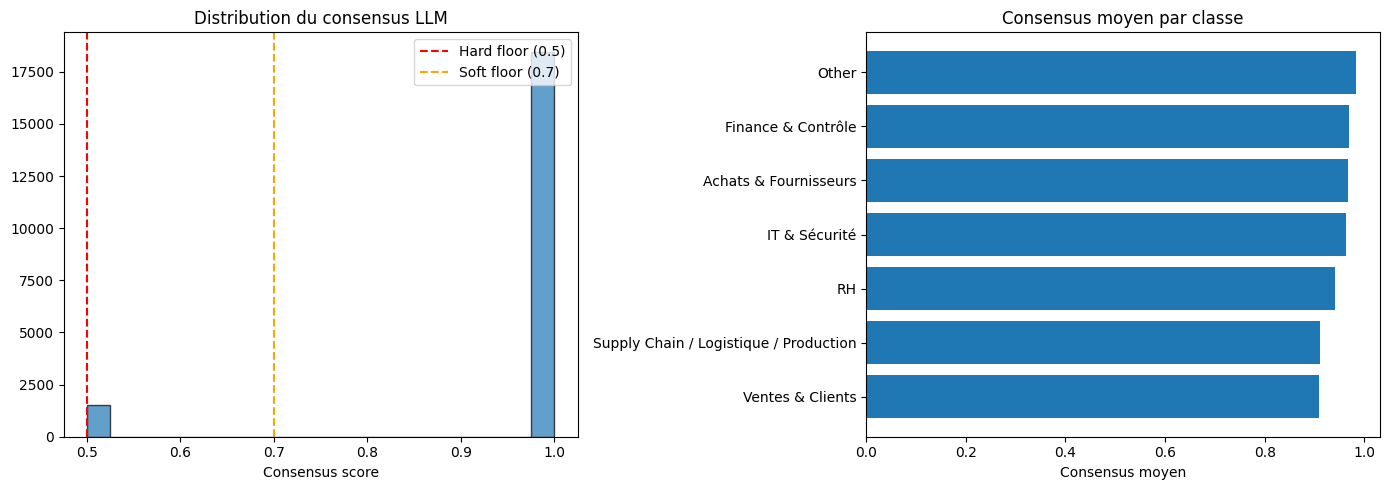


=== Consensus moyen par classe ===
                                         mean  median  min  count
business_domain                                                  
Ventes & Clients                        0.909     1.0  0.5    345
Supply Chain / Logistique / Production  0.911     1.0  0.5   1502
RH                                      0.941     1.0  0.5    855
IT & Sécurité                           0.963     1.0  0.5   5303
Achats & Fournisseurs                   0.966     1.0  0.5   2165
Finance & Contrôle                      0.968     1.0  0.5   7509
Other                                   0.982     1.0  0.5   2321


In [9]:
consensus = df_raw["llm_consensus_score"]

print("=== Distribution du consensus LLM ===")
print(consensus.describe())
print()

# Buckets de qualité
buckets = pd.cut(consensus, bins=[0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01],
                 labels=["≤0.5","0.5-0.6","0.6-0.7","0.7-0.8","0.8-0.9","0.9-1.0"],
                 right=False)
bucket_counts = buckets.value_counts().sort_index()
print("=== Répartition par tranche de consensus ===")
for b, n in bucket_counts.items():
    pct = 100*n/len(df_raw)
    bar = "█" * int(pct)
    print(f"  {b:8s}  {n:5d}  ({pct:5.1f}%) {bar}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(consensus, bins=20, edgecolor="black", alpha=0.7)
axes[0].axvline(CONSENSUS_HARD_FLOOR, color="red", ls="--", label=f"Hard floor ({CONSENSUS_HARD_FLOOR})")
axes[0].axvline(CONSENSUS_SOFT_FLOOR, color="orange", ls="--", label=f"Soft floor ({CONSENSUS_SOFT_FLOOR})")
axes[0].set_title("Distribution du consensus LLM")
axes[0].set_xlabel("Consensus score")
axes[0].legend()

# Consensus par classe
class_consensus = df_raw.groupby(TARGET)["llm_consensus_score"].agg(["mean","median","min","count"])
class_consensus = class_consensus.sort_values("mean")
axes[1].barh(class_consensus.index, class_consensus["mean"])
axes[1].set_title("Consensus moyen par classe")
axes[1].set_xlabel("Consensus moyen")
plt.tight_layout()
plt.show()

print("\n=== Consensus moyen par classe ===")
print(class_consensus.round(3))


### 1.2 Analyse des désaccords LLM

In [10]:
def parse_votes(votes_json):
    try:
        votes = json.loads(votes_json)
        return [v.get("business_domain", "?") for v in votes]
    except:
        return []

df_raw["_votes"] = df_raw["llm_votes_json"].apply(parse_votes)
df_raw["_n_votes"] = df_raw["_votes"].apply(len)
df_raw["_n_unique_votes"] = df_raw["_votes"].apply(lambda v: len(set(v)))

# Paires de confusion LLM
disagreements = df_raw[df_raw["_n_unique_votes"] > 1].copy()
print(f"=== Lignes avec désaccord LLM : {len(disagreements)} ({100*len(disagreements)/len(df_raw):.1f}%) ===")

# Top paires de confusion
confusion_pairs = Counter()
for _, row in disagreements.iterrows():
    unique = sorted(set(row["_votes"]))
    if len(unique) == 2:
        confusion_pairs[tuple(unique)] += 1

print("\n=== Top paires de confusion LLM ===")
for pair, cnt in confusion_pairs.most_common(10):
    print(f"  {pair[0]:40s} ↔ {pair[1]:40s}  {cnt:4d} lignes")


=== Lignes avec désaccord LLM : 1527 (7.6%) ===

=== Top paires de confusion LLM ===
  IT & Sécurité                            ↔ Other                                      396 lignes
  Finance & Contrôle                       ↔ IT & Sécurité                              228 lignes
  Achats & Fournisseurs                    ↔ Finance & Contrôle                         118 lignes
  Finance & Contrôle                       ↔ Other                                      115 lignes
  IT & Sécurité                            ↔ Supply Chain / Logistique / Production     112 lignes
  Achats & Fournisseurs                    ↔ IT & Sécurité                               94 lignes
  Finance & Contrôle                       ↔ Supply Chain / Logistique / Production      70 lignes
  Other                                    ↔ Supply Chain / Logistique / Production      64 lignes
  Achats & Fournisseurs                    ↔ Supply Chain / Logistique / Production      49 lignes
  Other                 

### 1.3 Nettoyage et stratification de qualité

In [11]:
# === Stratégie de nettoyage ===
# 1. RETIRER : consensus == 0.5 avec seulement 2 votes (coin flip)
# 2. QUEUE REVUE : consensus < 0.7 → revue humaine
# 3. GARDER : consensus >= 0.7 → dataset gold

n_total = len(df_raw)

# Tier 1 : Gold (consensus >= soft_floor)
mask_gold = df_raw["llm_consensus_score"] >= CONSENSUS_SOFT_FLOOR
# Tier 2 : Review (entre hard et soft)
mask_review = (df_raw["llm_consensus_score"] >= CONSENSUS_HARD_FLOOR) & ~mask_gold
# Tier 3 : Reject (consensus == hard_floor avec 2 votes = coin flip)
mask_coinflip = (df_raw["llm_consensus_score"] == CONSENSUS_HARD_FLOOR) & (df_raw["_n_votes"] == 2)
mask_reject = mask_coinflip

# Ajuster : les coin flips passent de review à reject
mask_review = mask_review & ~mask_reject

df_gold   = df_raw[mask_gold].copy()
df_review = df_raw[mask_review].copy()
df_reject = df_raw[mask_reject].copy()

print("=== Stratification de qualité ===")
print(f"  🟢 Gold    (consensus >= {CONSENSUS_SOFT_FLOOR}) : {len(df_gold):5d} ({100*len(df_gold)/n_total:.1f}%)")
print(f"  🟡 Review  ({CONSENSUS_HARD_FLOOR} < cons < {CONSENSUS_SOFT_FLOOR})  : {len(df_review):5d} ({100*len(df_review)/n_total:.1f}%)")
print(f"  🔴 Reject  (coin flip, cons={CONSENSUS_HARD_FLOOR}, 2 votes) : {len(df_reject):5d} ({100*len(df_reject)/n_total:.1f}%)")
print(f"  Total : {len(df_gold)+len(df_review)+len(df_reject)}")

# Distribution par classe dans chaque tier
print("\n=== Distribution gold ===")
print(df_gold[TARGET].value_counts())
print(f"\n=== Distribution review ===")
print(df_review[TARGET].value_counts())


=== Stratification de qualité ===
  🟢 Gold    (consensus >= 0.7) : 18473 (92.4%)
  🟡 Review  (0.5 < cons < 0.7)  :     2 (0.0%)
  🔴 Reject  (coin flip, cons=0.5, 2 votes) :  1525 (7.6%)
  Total : 20000

=== Distribution gold ===
business_domain
Finance & Contrôle                        7033
IT & Sécurité                             4913
Other                                     2238
Achats & Fournisseurs                     2018
Supply Chain / Logistique / Production    1235
RH                                         754
Ventes & Clients                           282
Name: count, dtype: int64

=== Distribution review ===
business_domain
IT & Sécurité         1
Finance & Contrôle    1
Name: count, dtype: int64


### 1.4 Génération des files de revue humaine

In [12]:
# File de revue ciblée : on priorise les cas les plus utiles
# 1. Coin flips rejetés (si on veut les récupérer)
# 2. Faible consensus sur classes rares (Ventes & Clients, RH)
# 3. Confusion IT ↔ Other (la paire #1 d'erreurs du modèle)

review_cols = [
    "asset_id", "technical_name", "source_ref", "column_names_text",
    "business_domain", "llm_consensus_score", "_votes",
]

# Queue 1 : tous les items à revoir
review_queue = df_review[review_cols].copy()
review_queue["review_reason"] = "low_consensus"

# Queue 2 : coin flips
coinflip_queue = df_reject[review_cols].copy()
coinflip_queue["review_reason"] = "coin_flip_reject"

# Queue 3 : confusion IT ↔ Other spécifique
it_other_confusion = df_raw[
    (df_raw["_n_unique_votes"] > 1) &
    (df_raw["_votes"].apply(lambda v: "IT & Sécurité" in v and "Other" in v))
][review_cols].copy()
it_other_confusion["review_reason"] = "IT_Other_confusion"

# Assemblage et dédoublication
full_review = pd.concat([review_queue, coinflip_queue, it_other_confusion], ignore_index=True)
full_review = full_review.drop_duplicates(subset=["asset_id"])

print(f"=== File de revue totale : {len(full_review)} lignes ===")
print(full_review["review_reason"].value_counts())

# Export
review_path = OUTPUT_DIR / "review_queue_labels.csv"
full_review.to_csv(review_path, index=False)
print(f"\nExporté : {review_path}")
print("\nExemples :")
print(full_review.head(10).to_string(index=False))


=== File de revue totale : 1527 lignes ===
review_reason
coin_flip_reject    1525
low_consensus          2
Name: count, dtype: int64

Exporté : artifacts_business_domain\review_queue_labels.csv

Exemples :
 asset_id            technical_name         source_ref                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

### 1.5 Constitution du dataset gold

In [13]:
# Le dataset gold est celui sur lequel on entraîne le modèle de production.
# On utilise les lignes GOLD uniquement.
# Les lignes REVIEW seront réintégrées après validation humaine.

# On conserve les poids : consensus comme sample_weight
df_train_source = df_gold.copy()
sample_weights_gold = df_train_source["llm_consensus_score"].fillna(1.0).astype(np.float32).values

print(f"=== Dataset gold pour entraînement ===")
print(f"  Taille : {len(df_train_source)}")
print(f"  Distribution :")
print(df_train_source[TARGET].value_counts())
print(f"\n  Ratio déséquilibre : {df_train_source[TARGET].value_counts().max() / df_train_source[TARGET].value_counts().min():.1f}x")
print(f"  Consensus moyen : {sample_weights_gold.mean():.3f}")

# Vérification : le gold garde une distribution raisonnable
gold_dist = df_train_source[TARGET].value_counts(normalize=True)
raw_dist = df_raw[TARGET].value_counts(normalize=True)
drift = (gold_dist - raw_dist).abs()
print(f"\n  Drift max distribution gold vs raw : {drift.max():.3f} (OK si < 0.05)")


=== Dataset gold pour entraînement ===
  Taille : 18473
  Distribution :
business_domain
Finance & Contrôle                        7033
IT & Sécurité                             4913
Other                                     2238
Achats & Fournisseurs                     2018
Supply Chain / Logistique / Production    1235
RH                                         754
Ventes & Clients                           282
Name: count, dtype: int64

  Ratio déséquilibre : 24.9x
  Consensus moyen : 1.000

  Drift max distribution gold vs raw : 0.008 (OK si < 0.05)


---
# PHASE 2 — Geler le modèle

On entraîne le modèle **final** sur le dataset gold, avec :
- Le pipeline v2 complet (TF-IDF column_names + semantic features)
- Le modèle champion : **LinearSVC** (Macro-F1 = 0.878 en v2)
- **Calibration Platt** pour obtenir des probabilités (LinearSVC n'en donne pas nativement)
- Versioning complet des artefacts


### 2.1 Préparation du dataset gold

In [14]:
# Extraire les semantic features AVANT de drop les colonnes
with timer("semantic features (gold)"):
    sem_gold = build_semantic_features(df_train_source)

# Drop fuites + colonnes bruit
all_drop = [c for c in DROP_COLS + DROPPED_TEXT_COLS + ["_votes","_n_votes","_n_unique_votes"]
            if c in df_train_source.columns]
df_clean = df_train_source.drop(columns=all_drop)

with timer("prepare (gold)"):
    df_prepared = prepare_dataframe(df_clean)

X_gold = df_prepared.drop(columns=[TARGET])
y_gold = df_prepared[TARGET].astype(str)

label_encoder = LabelEncoder()
y_gold_enc = label_encoder.fit_transform(y_gold)

print(f"X_gold : {X_gold.shape}")
print(f"Classes : {list(label_encoder.classes_)}")


[semantic features (gold)] 0.41s
[prepare (gold)] 0.47s
X_gold : (18473, 18)
Classes : ['Achats & Fournisseurs', 'Finance & Contrôle', 'IT & Sécurité', 'Other', 'RH', 'Supply Chain / Logistique / Production', 'Ventes & Clients']


### 2.2 Validation finale (CV sur gold)

In [15]:
# Split pour validation hold-out + CV
X_train, X_holdout, y_train, y_holdout, w_train, w_holdout, sem_train, sem_holdout = \
    train_test_split(X_gold, y_gold_enc, sample_weights_gold, sem_gold,
                     test_size=0.15, random_state=RANDOM_STATE, stratify=y_gold_enc)

# --- Fit TF-IDF ---
def fit_tfidf(X_tr, X_te, cols, analyzer, ngrams, max_feat, stopwords=None):
    tr_text = X_tr[cols].fillna("").astype(str).agg(" ".join, axis=1)
    te_text = X_te[cols].fillna("").astype(str).agg(" ".join, axis=1)
    vec = TfidfVectorizer(analyzer=analyzer, ngram_range=ngrams, min_df=3,
                          max_features=max_feat, sublinear_tf=True, dtype=np.float32,
                          stop_words=list(stopwords) if stopwords and analyzer=="word" else None)
    return vec, vec.fit_transform(tr_text), vec.transform(te_text)

with timer("TF-IDF"):
    char_vec, Xtr_char, Xho_char = fit_tfidf(X_train, X_holdout, TEXT_COLS_CHAR, "char_wb", CHAR_NGRAMS, CHAR_MAX_FEATURES)
    word_vec, Xtr_word, Xho_word = fit_tfidf(X_train, X_holdout, TEXT_COLS_WORD, "word", WORD_NGRAMS, WORD_MAX_FEATURES, SQL_STOPWORDS)

# --- Engineered + semantic ---
with timer("features"):
    eng_train = build_engineered_features(X_train)
    eng_holdout = build_engineered_features(X_holdout)

num_tr = pd.concat([X_train[NUM_COLS].astype(np.float32).reset_index(drop=True),
                    eng_train.reset_index(drop=True),
                    sem_train.reset_index(drop=True)], axis=1)
num_ho = pd.concat([X_holdout[NUM_COLS].astype(np.float32).reset_index(drop=True),
                    eng_holdout.reset_index(drop=True),
                    sem_holdout.reset_index(drop=True)], axis=1)

num_scaler = StandardScaler(with_mean=False)
Xtr_num = csr_matrix(num_scaler.fit_transform(num_tr.values.astype(np.float32)))
Xho_num = csr_matrix(num_scaler.transform(num_ho.values.astype(np.float32)))

def make_ohe():
    try: return OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except: return OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)
ohe = make_ohe()
Xtr_cat = ohe.fit_transform(X_train[CAT_COLS].astype(str))
Xho_cat = ohe.transform(X_holdout[CAT_COLS].astype(str))

X_train_final = hstack([Xtr_char, Xtr_word, Xtr_num, Xtr_cat]).tocsr()
X_holdout_final = hstack([Xho_char, Xho_word, Xho_num, Xho_cat]).tocsr()

num_feat_names = list(num_tr.columns)
cat_feat_names = list(ohe.get_feature_names_out(CAT_COLS))
all_feat_names = ([f"char__{n}" for n in char_vec.get_feature_names_out()] +
                  [f"word__{n}" for n in word_vec.get_feature_names_out()] +
                  num_feat_names + cat_feat_names)

print(f"X_train_final : {X_train_final.shape}")
print(f"X_holdout_final : {X_holdout_final.shape}")


[TF-IDF] 3.14s
[features] 1.78s
X_train_final : (15702, 56503)
X_holdout_final : (2771, 56503)


In [16]:
# Validation hold-out sur le gold
svc = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=4000)
with timer("LinearSVC fit (validation)"):
    svc.fit(X_train_final, y_train, sample_weight=w_train)

pred_ho = svc.predict(X_holdout_final)
macro_ho = f1_score(y_holdout, pred_ho, average="macro")
weighted_ho = f1_score(y_holdout, pred_ho, average="weighted")
print(f"\n=== Validation hold-out (gold) ===")
print(f"  Macro-F1    : {macro_ho:.4f}")
print(f"  Weighted-F1 : {weighted_ho:.4f}")
print()
print(classification_report(y_holdout, pred_ho, target_names=label_encoder.classes_, digits=4))


[LinearSVC fit (validation)] 55.15s

=== Validation hold-out (gold) ===
  Macro-F1    : 0.8918
  Weighted-F1 : 0.9234

                                        precision    recall  f1-score   support

                 Achats & Fournisseurs     0.9458    0.9208    0.9331       303
                    Finance & Contrôle     0.9637    0.9555    0.9595      1055
                         IT & Sécurité     0.9170    0.9294    0.9232       737
                                 Other     0.8254    0.8720    0.8480       336
                                    RH     0.9579    0.8053    0.8750       113
Supply Chain / Logistique / Production     0.8925    0.8973    0.8949       185
                      Ventes & Clients     0.7660    0.8571    0.8090        42

                              accuracy                         0.9231      2771
                             macro avg     0.8954    0.8911    0.8918      2771
                          weighted avg     0.9245    0.9231    0.9234      2771

### 2.3 Entraînement final sur 100% du gold

In [17]:
# --- Refit TF-IDF sur TOUT le gold ---
def fit_tfidf_full(X, cols, analyzer, ngrams, max_feat, stopwords=None):
    text = X[cols].fillna("").astype(str).agg(" ".join, axis=1)
    vec = TfidfVectorizer(analyzer=analyzer, ngram_range=ngrams, min_df=3,
                          max_features=max_feat, sublinear_tf=True, dtype=np.float32,
                          stop_words=list(stopwords) if stopwords and analyzer=="word" else None)
    return vec, vec.fit_transform(text)

with timer("TF-IDF full"):
    char_vec_prod, X_char_full = fit_tfidf_full(X_gold, TEXT_COLS_CHAR, "char_wb", CHAR_NGRAMS, CHAR_MAX_FEATURES)
    word_vec_prod, X_word_full = fit_tfidf_full(X_gold, TEXT_COLS_WORD, "word", WORD_NGRAMS, WORD_MAX_FEATURES, SQL_STOPWORDS)

with timer("features full"):
    eng_full = build_engineered_features(X_gold)

num_full = pd.concat([X_gold[NUM_COLS].astype(np.float32).reset_index(drop=True),
                      eng_full.reset_index(drop=True),
                      sem_gold.reset_index(drop=True)], axis=1)

num_scaler_prod = StandardScaler(with_mean=False)
X_num_full = csr_matrix(num_scaler_prod.fit_transform(num_full.values.astype(np.float32)))

ohe_prod = make_ohe()
X_cat_full = ohe_prod.fit_transform(X_gold[CAT_COLS].astype(str))

X_full_final = hstack([X_char_full, X_word_full, X_num_full, X_cat_full]).tocsr()
print(f"X_full_final : {X_full_final.shape}")

# --- Modèle de production ---
with timer("LinearSVC production fit"):
    svc_prod = LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=4000)
    svc_prod.fit(X_full_final, y_gold_enc, sample_weight=sample_weights_gold)

# --- Calibration Platt ---
if CALIBRATE:
    with timer("Calibration Platt (CalibratedClassifierCV)"):
        calibrated_model = CalibratedClassifierCV(svc_prod, cv=5, method="sigmoid")
        calibrated_model.fit(X_full_final, y_gold_enc, sample_weight=sample_weights_gold)
    print("Modèle calibré — predict_proba() disponible")
else:
    calibrated_model = None

print(f"\nModèle de production entraîné sur {X_full_final.shape[0]} lignes gold.")


[TF-IDF full] 4.29s
[features full] 2.61s
X_full_final : (18473, 62749)
[LinearSVC production fit] 49.56s
[Calibration Platt (CalibratedClassifierCV)] 203.42s
Modèle calibré — predict_proba() disponible

Modèle de production entraîné sur 18473 lignes gold.


### 2.4 Versioning et sauvegarde des artefacts gelés

In [18]:
# Hash du dataset pour traçabilité
with open(DATA_PATH, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()[:12]

prod_num_feat = list(num_full.columns)
prod_cat_feat = list(ohe_prod.get_feature_names_out(CAT_COLS))
prod_all_feat = ([f"char__{n}" for n in char_vec_prod.get_feature_names_out()] +
                 [f"word__{n}" for n in word_vec_prod.get_feature_names_out()] +
                 prod_num_feat + prod_cat_feat)

artifacts_prod = {
    # --- Metadata ---
    "pipeline_version": PIPELINE_VERSION,
    "timestamp": TIMESTAMP,
    "data_hash": data_hash,
    "data_path": str(DATA_PATH),
    "gold_size": len(df_train_source),
    "gold_consensus_floor": CONSENSUS_SOFT_FLOOR,
    "holdout_macro_f1": float(macro_ho),
    "holdout_weighted_f1": float(weighted_ho),
    "model_type": PROD_MODEL,
    "calibrated": CALIBRATE,

    # --- Objets ajustés ---
    "label_encoder": label_encoder,
    "char_vectorizer": char_vec_prod,
    "word_vectorizer": word_vec_prod,
    "one_hot_encoder": ohe_prod,
    "num_scaler": num_scaler_prod,
    "model": svc_prod,
    "calibrated_model": calibrated_model,

    # --- Config ---
    "config": {
        "TARGET": TARGET, "DROP_COLS": DROP_COLS,
        "DROPPED_TEXT_COLS": DROPPED_TEXT_COLS,
        "TEXT_COLS_CHAR": TEXT_COLS_CHAR, "TEXT_COLS_WORD": TEXT_COLS_WORD,
        "NUM_COLS": NUM_COLS, "CAT_COLS": CAT_COLS,
        "SQL_STOPWORDS": SQL_STOPWORDS,
        "KNOWN_SEMANTIC_LABELS": KNOWN_SEMANTIC_LABELS,
    },
    "feature_names": prod_all_feat,
    "numeric_feature_names": prod_num_feat,
    "domain_keywords": DOMAIN_KEYWORDS,
    "ps_module_prefixes": PS_MODULE_PREFIXES,
}

artifact_path = OUTPUT_DIR / f"production_pipeline_{PIPELINE_VERSION}_{TIMESTAMP}.joblib"
joblib.dump(artifacts_prod, artifact_path, compress=3)

# Copie "latest"
latest_path = OUTPUT_DIR / "production_pipeline_latest.joblib"
joblib.dump(artifacts_prod, latest_path, compress=3)

print(f"=== Artefacts gelés ===")
print(f"  Version      : {PIPELINE_VERSION}")
print(f"  Timestamp    : {TIMESTAMP}")
print(f"  Data hash    : {data_hash}")
print(f"  Gold size    : {len(df_train_source)}")
print(f"  Holdout F1   : macro={macro_ho:.4f}, weighted={weighted_ho:.4f}")
print(f"  Calibré      : {CALIBRATE}")
print(f"  Features     : {len(prod_all_feat)}")
print(f"  Fichier      : {artifact_path}")
print(f"  Latest       : {latest_path}")


=== Artefacts gelés ===
  Version      : v3.0
  Timestamp    : 20260421_110952
  Data hash    : 14df313f3030
  Gold size    : 18473
  Holdout F1   : macro=0.8918, weighted=0.9234
  Calibré      : True
  Features     : 62749
  Fichier      : artifacts_business_domain\production_pipeline_v3.0_20260421_110952.joblib
  Latest       : artifacts_business_domain\production_pipeline_latest.joblib


---
# PHASE 3 — Industrialiser l'inférence

Pipeline de scoring batch avec :
- Fonction unique `score_batch()` qui prend un DataFrame brut et retourne les prédictions + confiance
- Bandes de confiance (high / medium / low) pour le triage métier
- Détection de drift sur les inputs
- Logging structuré


### 3.1 Pipeline d'inférence

In [19]:
def score_batch(df_new: pd.DataFrame, artifacts: dict) -> pd.DataFrame:
    """Score un DataFrame brut.

    Retourne un DataFrame avec les colonnes :
    - y_pred : classe prédite
    - confidence : probabilité max (si calibré) ou score de distance
    - confidence_band : 'high' / 'medium' / 'low'
    - y_pred_alt : 2e classe la plus probable
    """
    cfg = artifacts["config"]
    le  = artifacts["label_encoder"]
    classes = le.classes_

    # --- Semantic features AVANT drop ---
    if "column_value_semantics_text" in df_new.columns:
        sem = build_semantic_features(df_new)
    else:
        sem = pd.DataFrame(0, index=df_new.index,
                           columns=[f"sem_{l}" for l in KNOWN_SEMANTIC_LABELS] +
                                   [f"ratio_{l}" for l in ["financial_amount","person_identifier",
                                    "user_identifier","quantity","processing_identifier","flag","status"]])

    # --- Drop fuites ---
    present_drop = [c for c in cfg["DROP_COLS"] + cfg["DROPPED_TEXT_COLS"]
                    if c in df_new.columns]
    df_work = df_new.drop(columns=present_drop, errors="ignore")
    df_p = prepare_dataframe(df_work)

    # --- TF-IDF ---
    char_txt = df_p[cfg["TEXT_COLS_CHAR"]].fillna("").astype(str).agg(" ".join, axis=1)
    word_txt = df_p[cfg["TEXT_COLS_WORD"]].fillna("").astype(str).agg(" ".join, axis=1)
    X_char = artifacts["char_vectorizer"].transform(char_txt)
    X_word = artifacts["word_vectorizer"].transform(word_txt)

    # --- Engineered + semantic ---
    eng = build_engineered_features(df_p)
    num_df = pd.concat([df_p[cfg["NUM_COLS"]].astype(np.float32).reset_index(drop=True),
                        eng.reset_index(drop=True),
                        sem.reset_index(drop=True)], axis=1)
    X_num = csr_matrix(artifacts["num_scaler"].transform(num_df.values.astype(np.float32)))

    # --- Cat ---
    X_cat = artifacts["one_hot_encoder"].transform(df_p[cfg["CAT_COLS"]].astype(str))

    # --- Assemblage ---
    X_all = hstack([X_char, X_word, X_num, X_cat]).tocsr()

    # --- Prédiction + confiance ---
    cal = artifacts.get("calibrated_model")
    if cal is not None:
        probas = cal.predict_proba(X_all)
        y_pred_enc = probas.argmax(axis=1)
        confidence = probas.max(axis=1)
        # 2e classe
        sorted_idx = np.argsort(-probas, axis=1)
        y_alt_enc = sorted_idx[:, 1]
    else:
        model = artifacts["model"]
        y_pred_enc = model.predict(X_all)
        # Distance au hyperplan comme proxy de confiance
        decision = model.decision_function(X_all)
        if decision.ndim == 1:
            confidence = np.abs(decision)
        else:
            sorted_d = np.sort(decision, axis=1)
            confidence = sorted_d[:, -1] - sorted_d[:, -2]  # marge entre top 2
        # Normaliser en [0, 1]
        confidence = (confidence - confidence.min()) / (confidence.max() - confidence.min() + 1e-8)
        sorted_idx = np.argsort(-decision, axis=1)
        y_alt_enc = sorted_idx[:, 1]

    # --- Construction du résultat ---
    result = pd.DataFrame({
        "y_pred": le.inverse_transform(y_pred_enc),
        "y_pred_alt": le.inverse_transform(y_alt_enc),
        "confidence": np.round(confidence, 4),
    }, index=df_new.index)

    # Bandes de confiance
    result["confidence_band"] = pd.cut(
        result["confidence"],
        bins=[0, 0.5, 0.8, 1.01],
        labels=["low", "medium", "high"],
        right=False,
    )

    return result

print("Fonction score_batch() définie.")


Fonction score_batch() définie.


### 3.2 Monitoring de drift

In [20]:
def compute_drift_report(df_new: pd.DataFrame, reference_stats: dict) -> dict:
    """Compare les statistiques du batch courant vs. le dataset d'entraînement.

    Retourne un rapport de drift avec alertes si les distributions changent.
    """
    report = {"timestamp": datetime.datetime.now().isoformat(), "n_rows": len(df_new)}
    alerts = []

    # 1. Distribution des classes prédites (si disponible)
    if "y_pred" in df_new.columns:
        pred_dist = df_new["y_pred"].value_counts(normalize=True).to_dict()
        report["pred_distribution"] = pred_dist

        for cls, ref_pct in reference_stats.get("class_distribution", {}).items():
            new_pct = pred_dist.get(cls, 0)
            if abs(new_pct - ref_pct) > 0.10:
                alerts.append(f"DRIFT classe '{cls}': ref={ref_pct:.2%} -> new={new_pct:.2%}")

    # 2. Distribution de confiance
    if "confidence" in df_new.columns:
        mean_conf = df_new["confidence"].mean()
        report["mean_confidence"] = mean_conf
        ref_conf = reference_stats.get("mean_confidence", 0.9)
        if mean_conf < ref_conf - 0.05:
            alerts.append(f"DRIFT confiance: ref={ref_conf:.3f} -> new={mean_conf:.3f}")

        low_pct = (df_new["confidence_band"] == "low").mean()
        report["low_confidence_pct"] = low_pct
        if low_pct > 0.15:
            alerts.append(f"ALERTE: {low_pct:.1%} de prédictions à faible confiance")

    # 3. Caractéristiques structurelles
    for col in ["field_count", "avg_data_length"]:
        if col in df_new.columns:
            new_mean = df_new[col].astype(float).mean()
            ref_mean = reference_stats.get(f"mean_{col}", new_mean)
            if abs(new_mean - ref_mean) / max(ref_mean, 1) > 0.3:
                alerts.append(f"DRIFT {col}: ref={ref_mean:.1f} -> new={new_mean:.1f}")

    report["alerts"] = alerts
    report["status"] = "OK" if len(alerts) == 0 else f"ALERT ({len(alerts)})"
    return report

# Calculer les stats de référence depuis le gold
reference_stats = {
    "class_distribution": df_train_source[TARGET].value_counts(normalize=True).to_dict(),
    "mean_confidence": 0.90,  # baseline attendue
    "mean_field_count": df_train_source["field_count"].astype(float).mean(),
    "mean_avg_data_length": df_train_source["avg_data_length"].astype(float).mean(),
}

print("Stats de référence pour monitoring :")
for k, v in reference_stats.items():
    if isinstance(v, dict):
        print(f"  {k}:")
        for cls, pct in sorted(v.items(), key=lambda x: -x[1]):
            print(f"    {cls:40s} {pct:.3f}")
    else:
        print(f"  {k}: {v}")


Stats de référence pour monitoring :
  class_distribution:
    Finance & Contrôle                       0.381
    IT & Sécurité                            0.266
    Other                                    0.121
    Achats & Fournisseurs                    0.109
    Supply Chain / Logistique / Production   0.067
    RH                                       0.041
    Ventes & Clients                         0.015
  mean_confidence: 0.9
  mean_field_count: 22.743517566177665
  mean_avg_data_length: 29.776865486760418


---
# PHASE 4 — Exploitation métier

On score **l'intégralité** du dataset et on produit les livrables pour les équipes :
1. Dataset enrichi avec prédictions + confiance
2. Rapport de couverture par domaine
3. File de revue humaine ciblée (prédictions à faible confiance)
4. Exports CSV prêts à l'emploi


### 4.1 Scoring complet du dataset

In [21]:
with timer("Scoring complet"):
    scores = score_batch(df_raw, artifacts_prod)

# Joindre au dataset original
df_scored = df_raw.copy()
df_scored["y_pred"] = scores["y_pred"].values
df_scored["y_pred_alt"] = scores["y_pred_alt"].values
df_scored["confidence"] = scores["confidence"].values
df_scored["confidence_band"] = scores["confidence_band"].values

# Comparer avec le label LLM
df_scored["match_llm"] = (df_scored["y_pred"] == df_scored[TARGET]).astype(int)

print(f"=== Scoring complet : {len(df_scored)} lignes ===")
print(f"  Accord modèle-LLM : {df_scored['match_llm'].mean():.1%}")
print(f"  Confiance moyenne  : {df_scored['confidence'].mean():.3f}")
print()
print("=== Distribution des bandes de confiance ===")
print(df_scored["confidence_band"].value_counts())


[Scoring complet] 6.15s
=== Scoring complet : 20000 lignes ===
  Accord modèle-LLM : 95.7%
  Confiance moyenne  : 0.909

=== Distribution des bandes de confiance ===
confidence_band
high      17217
medium     2629
low         154
Name: count, dtype: int64


### 4.2 Rapport de couverture métier

In [22]:
print("=" * 70)
print("   RAPPORT DE COUVERTURE MÉTIER")
print("=" * 70)

# Par domaine prédit
domain_report = df_scored.groupby("y_pred").agg(
    n_assets=("asset_id", "count"),
    confidence_mean=("confidence", "mean"),
    confidence_min=("confidence", "min"),
    pct_high_conf=("confidence_band", lambda x: (x == "high").mean()),
    pct_match_llm=("match_llm", "mean"),
).sort_values("n_assets", ascending=False)

domain_report["pct_total"] = domain_report["n_assets"] / len(df_scored)

print("\n=== Couverture par domaine ===")
for dom, row in domain_report.iterrows():
    print(f"\n  📂 {dom}")
    print(f"     Assets     : {row['n_assets']:5.0f} ({row['pct_total']:.1%})")
    print(f"     Confiance  : moy={row['confidence_mean']:.3f}, min={row['confidence_min']:.3f}")
    print(f"     % haute conf : {row['pct_high_conf']:.1%}")
    print(f"     Accord LLM : {row['pct_match_llm']:.1%}")

# Désaccords modèle vs LLM
disagreements_model = df_scored[df_scored["match_llm"] == 0]
print(f"\n\n=== Désaccords modèle vs LLM : {len(disagreements_model)} ({100*len(disagreements_model)/len(df_scored):.1f}%) ===")
confusion = disagreements_model.groupby([TARGET, "y_pred"]).size().reset_index(name="n").sort_values("n", ascending=False)
print(confusion.head(10).to_string(index=False))


   RAPPORT DE COUVERTURE MÉTIER

=== Couverture par domaine ===

  📂 Finance & Contrôle
     Assets     :  7374 (36.9%)
     Confiance  : moy=0.951, min=0.321
     % haute conf : 93.2%
     Accord LLM : 98.5%

  📂 IT & Sécurité
     Assets     :  5348 (26.7%)
     Confiance  : moy=0.902, min=0.355
     % haute conf : 86.0%
     Accord LLM : 95.0%

  📂 Other
     Assets     :  2578 (12.9%)
     Confiance  : moy=0.836, min=0.327
     % haute conf : 74.0%
     Accord LLM : 88.2%

  📂 Achats & Fournisseurs
     Assets     :  2184 (10.9%)
     Confiance  : moy=0.910, min=0.377
     % haute conf : 86.8%
     Accord LLM : 95.4%

  📂 Supply Chain / Logistique / Production
     Assets     :  1400 (7.0%)
     Confiance  : moy=0.882, min=0.311
     % haute conf : 79.6%
     Accord LLM : 97.1%

  📂 RH
     Assets     :   808 (4.0%)
     Confiance  : moy=0.874, min=0.327
     % haute conf : 76.2%
     Accord LLM : 97.0%

  📂 Ventes & Clients
     Assets     :   308 (1.5%)
     Confiance  : moy=0.83

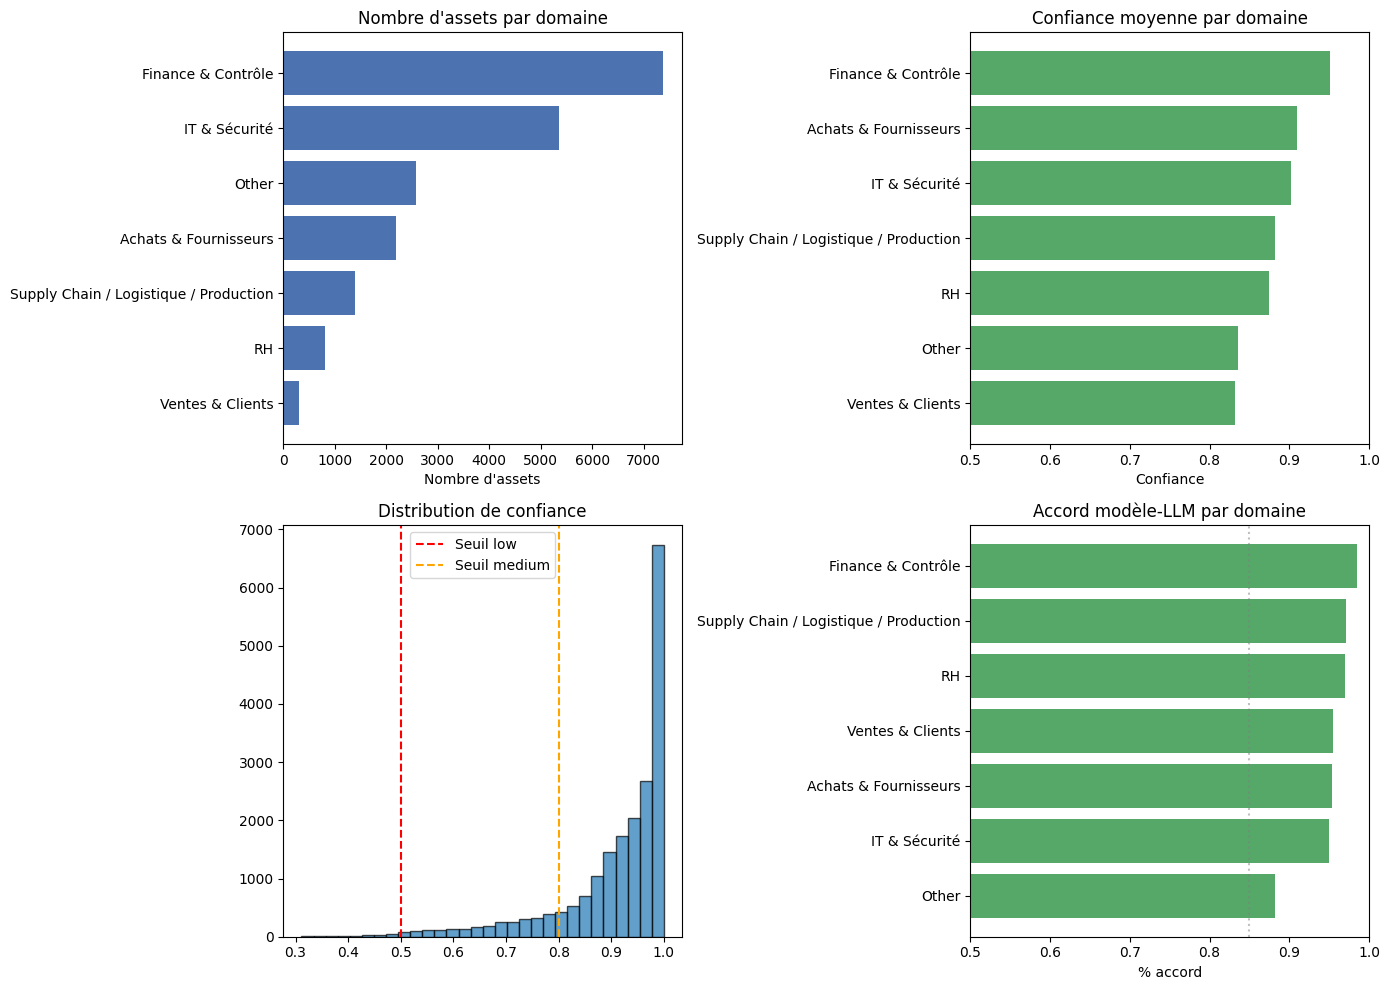

In [23]:
# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution par domaine
ax = axes[0, 0]
counts = df_scored["y_pred"].value_counts().sort_values()
ax.barh(counts.index, counts.values, color="#4C72B0")
ax.set_title("Nombre d'assets par domaine")
ax.set_xlabel("Nombre d'assets")

# 2. Confiance par domaine
ax = axes[0, 1]
conf_by_dom = df_scored.groupby("y_pred")["confidence"].mean().sort_values()
ax.barh(conf_by_dom.index, conf_by_dom.values, color="#55A868")
ax.set_title("Confiance moyenne par domaine")
ax.set_xlabel("Confiance")
ax.set_xlim(0.5, 1.0)

# 3. Distribution de confiance
ax = axes[1, 0]
ax.hist(df_scored["confidence"], bins=30, edgecolor="black", alpha=0.7)
ax.axvline(0.5, color="red", ls="--", label="Seuil low")
ax.axvline(0.8, color="orange", ls="--", label="Seuil medium")
ax.set_title("Distribution de confiance")
ax.legend()

# 4. Accord modèle vs LLM par domaine
ax = axes[1, 1]
match_by_dom = df_scored.groupby("y_pred")["match_llm"].mean().sort_values()
colors = ["#C44E52" if v < 0.85 else "#55A868" for v in match_by_dom.values]
ax.barh(match_by_dom.index, match_by_dom.values, color=colors)
ax.set_title("Accord modèle-LLM par domaine")
ax.set_xlabel("% accord")
ax.set_xlim(0.5, 1.0)
ax.axvline(0.85, color="gray", ls=":", alpha=0.5)

plt.tight_layout()
plt.show()


### 4.3 File de revue métier ciblée

In [24]:
# On génère une file de revue pour les équipes métier :
# 1. Prédictions à FAIBLE confiance (le modèle hésite)
# 2. Désaccords modèle vs LLM (le modèle et le LLM ne sont pas d'accord)
# 3. Classes rares à vérifier (Ventes & Clients, RH)

REVIEW_COLS = [
    "asset_id", "technical_name", "source_ref", "column_names_text",
    TARGET, "y_pred", "y_pred_alt", "confidence", "confidence_band",
    "match_llm", "llm_consensus_score",
]

# Queue 1 : faible confiance
low_conf = df_scored[df_scored["confidence_band"] == "low"][REVIEW_COLS].copy()
low_conf["review_reason"] = "low_model_confidence"

# Queue 2 : désaccords modèle-LLM à haute confiance
# (le modèle est sûr mais dit autre chose que le LLM → potentielle erreur de label)
disagree_highconf = df_scored[
    (df_scored["match_llm"] == 0) &
    (df_scored["confidence"] >= 0.8)
][REVIEW_COLS].copy()
disagree_highconf["review_reason"] = "model_disagrees_with_llm_high_conf"

# Queue 3 : classes rares
rare_classes = df_scored[TARGET].value_counts()
rare_labels = rare_classes[rare_classes / len(df_scored) < 0.05].index.tolist()
rare_low = df_scored[
    (df_scored["y_pred"].isin(rare_labels)) &
    (df_scored["confidence"] < 0.85)
][REVIEW_COLS].copy()
rare_low["review_reason"] = "rare_class_uncertain"

# Assemblage
review_metier = pd.concat([low_conf, disagree_highconf, rare_low], ignore_index=True)
review_metier = review_metier.drop_duplicates(subset=["asset_id"])
review_metier = review_metier.sort_values("confidence")

print(f"=== File de revue métier : {len(review_metier)} lignes ===")
print(review_metier["review_reason"].value_counts())
print(f"\nClasses les plus représentées dans la file :")
print(review_metier["y_pred"].value_counts())


=== File de revue métier : 788 lignes ===
review_reason
rare_class_uncertain                  372
model_disagrees_with_llm_high_conf    262
low_model_confidence                  154
Name: count, dtype: int64

Classes les plus représentées dans la file :
y_pred
RH                                        255
Ventes & Clients                          134
IT & Sécurité                             129
Other                                     116
Finance & Contrôle                         70
Achats & Fournisseurs                      50
Supply Chain / Logistique / Production     34
Name: count, dtype: int64


### 4.4 Drift report

In [25]:
drift = compute_drift_report(df_scored, reference_stats)
print("=== Rapport de drift ===")
print(f"  Status : {drift['status']}")
print(f"  Lignes scorées : {drift['n_rows']}")
print(f"  Confiance moyenne : {drift.get('mean_confidence', 'N/A')}")
print(f"  % faible confiance : {drift.get('low_confidence_pct', 'N/A'):.1%}")
if drift["alerts"]:
    print("\n  ⚠️ Alertes :")
    for a in drift["alerts"]:
        print(f"    - {a}")
else:
    print("\n  ✅ Aucune alerte de drift")


=== Rapport de drift ===
  Status : OK
  Lignes scorées : 20000
  Confiance moyenne : 0.9087783100000001
  % faible confiance : 0.8%

  ✅ Aucune alerte de drift


### 4.5 Exports finaux

In [26]:
# 1. Dataset complet enrichi
scored_path = OUTPUT_DIR / "dataset_scored_full.csv"
export_cols = [
    "asset_id", "source_system", "asset_type", "technical_name", "source_ref",
    "column_names_text", "field_count",
    TARGET, "y_pred", "y_pred_alt", "confidence", "confidence_band",
    "match_llm", "llm_consensus_score",
]
df_scored[[c for c in export_cols if c in df_scored.columns]].to_csv(scored_path, index=False)
print(f"✅ Dataset scoré : {scored_path}")

# 2. File de revue labels (phase 1)
print(f"✅ Revue labels  : {OUTPUT_DIR / 'review_queue_labels.csv'}")

# 3. File de revue métier (phase 4)
review_path = OUTPUT_DIR / "review_queue_metier.csv"
review_metier.to_csv(review_path, index=False)
print(f"✅ Revue métier   : {review_path}")

# 4. Rapport de couverture
report_path = OUTPUT_DIR / "coverage_report.csv"
domain_report.to_csv(report_path)
print(f"✅ Rapport couverture : {report_path}")

# 5. Drift report
drift_path = OUTPUT_DIR / "drift_report.json"
with open(drift_path, "w") as f:
    json.dump(drift, f, indent=2, default=str)
print(f"✅ Drift report  : {drift_path}")

# 6. Artefacts pipeline
print(f"✅ Pipeline gelé : {latest_path}")

print(f"\n{'='*60}")
print(f"  Tous les fichiers dans : {OUTPUT_DIR.resolve()}")
print(f"{'='*60}")


✅ Dataset scoré : artifacts_business_domain\dataset_scored_full.csv
✅ Revue labels  : artifacts_business_domain\review_queue_labels.csv
✅ Revue métier   : artifacts_business_domain\review_queue_metier.csv
✅ Rapport couverture : artifacts_business_domain\coverage_report.csv
✅ Drift report  : artifacts_business_domain\drift_report.json
✅ Pipeline gelé : artifacts_business_domain\production_pipeline_latest.joblib

  Tous les fichiers dans : C:\Users\Salem\Desktop\Projets\pfe\Projet\LLM\artifacts_business_domain


---
# Annexe — Usage en production

### Scoring batch d'un nouveau fichier
```python
import joblib
import pandas as pd

# 1. Charger le pipeline gelé
arts = joblib.load("artifacts_business_domain/production_pipeline_latest.joblib")

# 2. Charger les nouvelles données
df_new = pd.read_csv("nouveaux_assets.csv")

# 3. Scorer
results = score_batch(df_new, arts)
df_new["business_domain_pred"] = results["y_pred"]
df_new["confidence"] = results["confidence"]
df_new["confidence_band"] = results["confidence_band"]

# 4. Filtrer les prédictions fiables
fiable = df_new[df_new["confidence_band"] == "high"]
a_revoir = df_new[df_new["confidence_band"] != "high"]
```

### Monitoring continu
```python
# Après chaque batch, vérifier le drift
ref_stats = arts["reference_stats"]  # ou charger séparément
drift = compute_drift_report(results, ref_stats)
if drift["status"] != "OK":
    print("⚠️ Drift détecté :", drift["alerts"])
```

### Réentraînement
Quand ré-entraîner :
- Drift détecté sur >3 batchs consécutifs
- Nouvelles classes métier identifiées
- Revue humaine complétée (labels corrigés → nouveau gold)

Processus :
1. Intégrer les labels corrigés dans le gold
2. Ré-exécuter la Phase 2 (freeze) avec le gold enrichi
3. Comparer les scores : le nouveau modèle doit avoir un Macro-F1 ≥ ancien
4. Si OK → déployer le nouveau pipeline (nouveau `production_pipeline_latest.joblib`)
